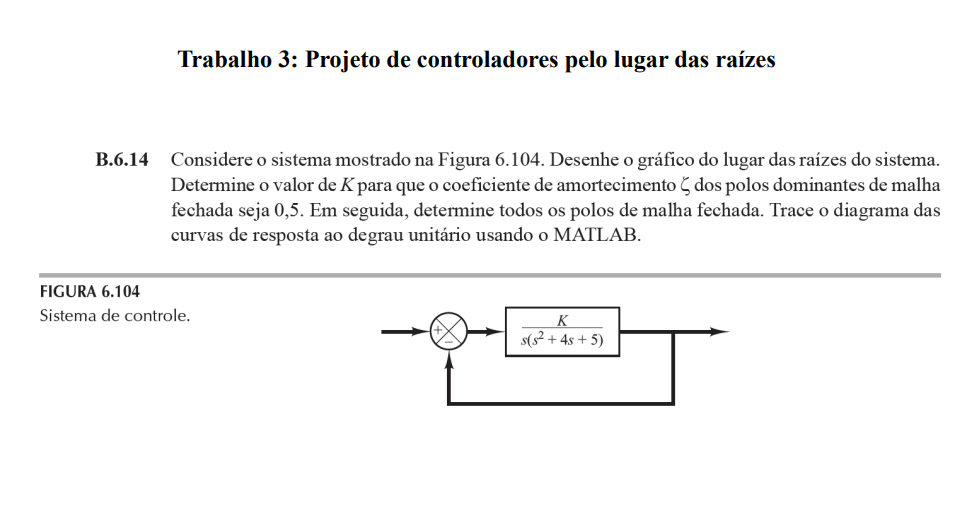

# Solução completa — Exercício **B.6.14**

## Enunciado (resumo)

Trabalho com o sistema em realimentação unitária negativa com

$$
G(s)=\frac{K}{s(s^2+4s+5)}
$$

**Preciso** traçar o **lugar das raízes**, **determinar** **\(K\)** para que o **coeficiente de amortecimento** dos **polos dominantes** em malha fechada seja **\(\zeta = 0.5\)**, **obter todos os polos** correspondentes e traçar a **resposta ao degrau unitário**.

---

## Passo 1 — Equação característica

Função de malha aberta (ganho \(K\) explícito):

$$
L(s)=G(s)=\frac{K}{s(s^2+4s+5)}
$$

Com \(H(s)=1\), escrevo a malha fechada como \(T(s)=\dfrac{L(s)}{1+L(s)}\). A condição \(1+L(s)=0\) dá

$$
s(s^2+4s+5)+K=0
\quad\Longrightarrow\quad
s^3+4s^2+5s+K=0.
$$

---

## Passo 2 — Polos em malha aberta (ponto de partida do lugar das raízes)

Do denominador \(s(s^2+4s+5)\):

- um polo em \(s=0\);
- dois polos em \(s=-2\pm j\) (raízes de \(s^2+4s+5=0\)).

São **3 polos** e **nenhum zero finito**: o lugar das raízes tem **3 ramos** que tendem ao infinito.

---

## Passo 3 — Condição \(\zeta=0.5\) sobre os polos dominantes (semi-plano superior)

Para um par complexo padrão \(s=-\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2}\), uso que o ângulo \(\phi\) medido a partir do **semi-eixo real negativo** até o vetor do polo satisfaz \(\cos\phi=\zeta\).

Para \(\zeta=0.5\):

$$
\phi=\arccos(0{,}5)=\frac{\pi}{3}\ \text{rad}\;(60^\circ).
$$

Em coordenadas com ângulo \(\theta\) medido a partir do **eixo real positivo** (semi-plano superior estável):

$$
\theta=\pi-\phi=\frac{2\pi}{3}.
$$

Procuro então os polos desejados do **par dominante** sobre a semi-reta

$$
s=r\,e^{j2\pi/3},\qquad r>0.
$$

Substituindo \(s=r\,e^{j2\pi/3}\) em \(s^3+4s^2+5s\) e impondo parte imaginária nula (porque \(K\) é real), cheguei a **\(r=5/4\)** e

$$
K=\frac{275}{64}=4{,}296875.
$$

Os dois polos complexos ficam em \(s=-\tfrac{5}{8}\pm j\tfrac{5\sqrt{3}}{8}\).

---

## Passo 4 — Todos os polos em malha fechada para esse \(K\)

Como \(s^3+4s^2+5s+K\) é de grau 3, aparecem **um polo real** e o **par complexo** acima. Interpretando posições: o polo real (mais à esquerda em \(s\)) costuma decair mais rápido; já o par em \(-0{,}625\pm j1{,}0825\) tende a **dominar** o transitório na prática (mais próximo do eixo imaginário).

---

## Passo 5 — Resposta ao degrau unitário

Fixando \(K\), **obtenho** a FT em malha fechada por realimentação unitária sobre \(G(s)\); em seguida **simulo** \(y(t)\) para entrada degrau \(1/s\) e **traço** \(y(t)\) **versus** \(t\).


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


 PROJETO POR AMORTECIMENTO — ζ desejado (polos dominantes) = 0.5
 Ganho K encontrado (interseção com reta ζ): K = 4.296875
 K racional (referência analítica): K = 275/64 = 4.296875

 Polos em malha fechada (rad/s):
   p1: -2.750000 +0.000000 j   |s|=2.750000   ζ≈1.000000
   p2: -0.625000 -1.082532 j   |s|=1.250000   ζ≈0.500000
   p3: -0.625000 +1.082532 j   |s|=1.250000   ζ≈0.500000

 Ganho DC da malha fechada T(0) = 1


/tmp/ipykernel_134853/2826131293.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


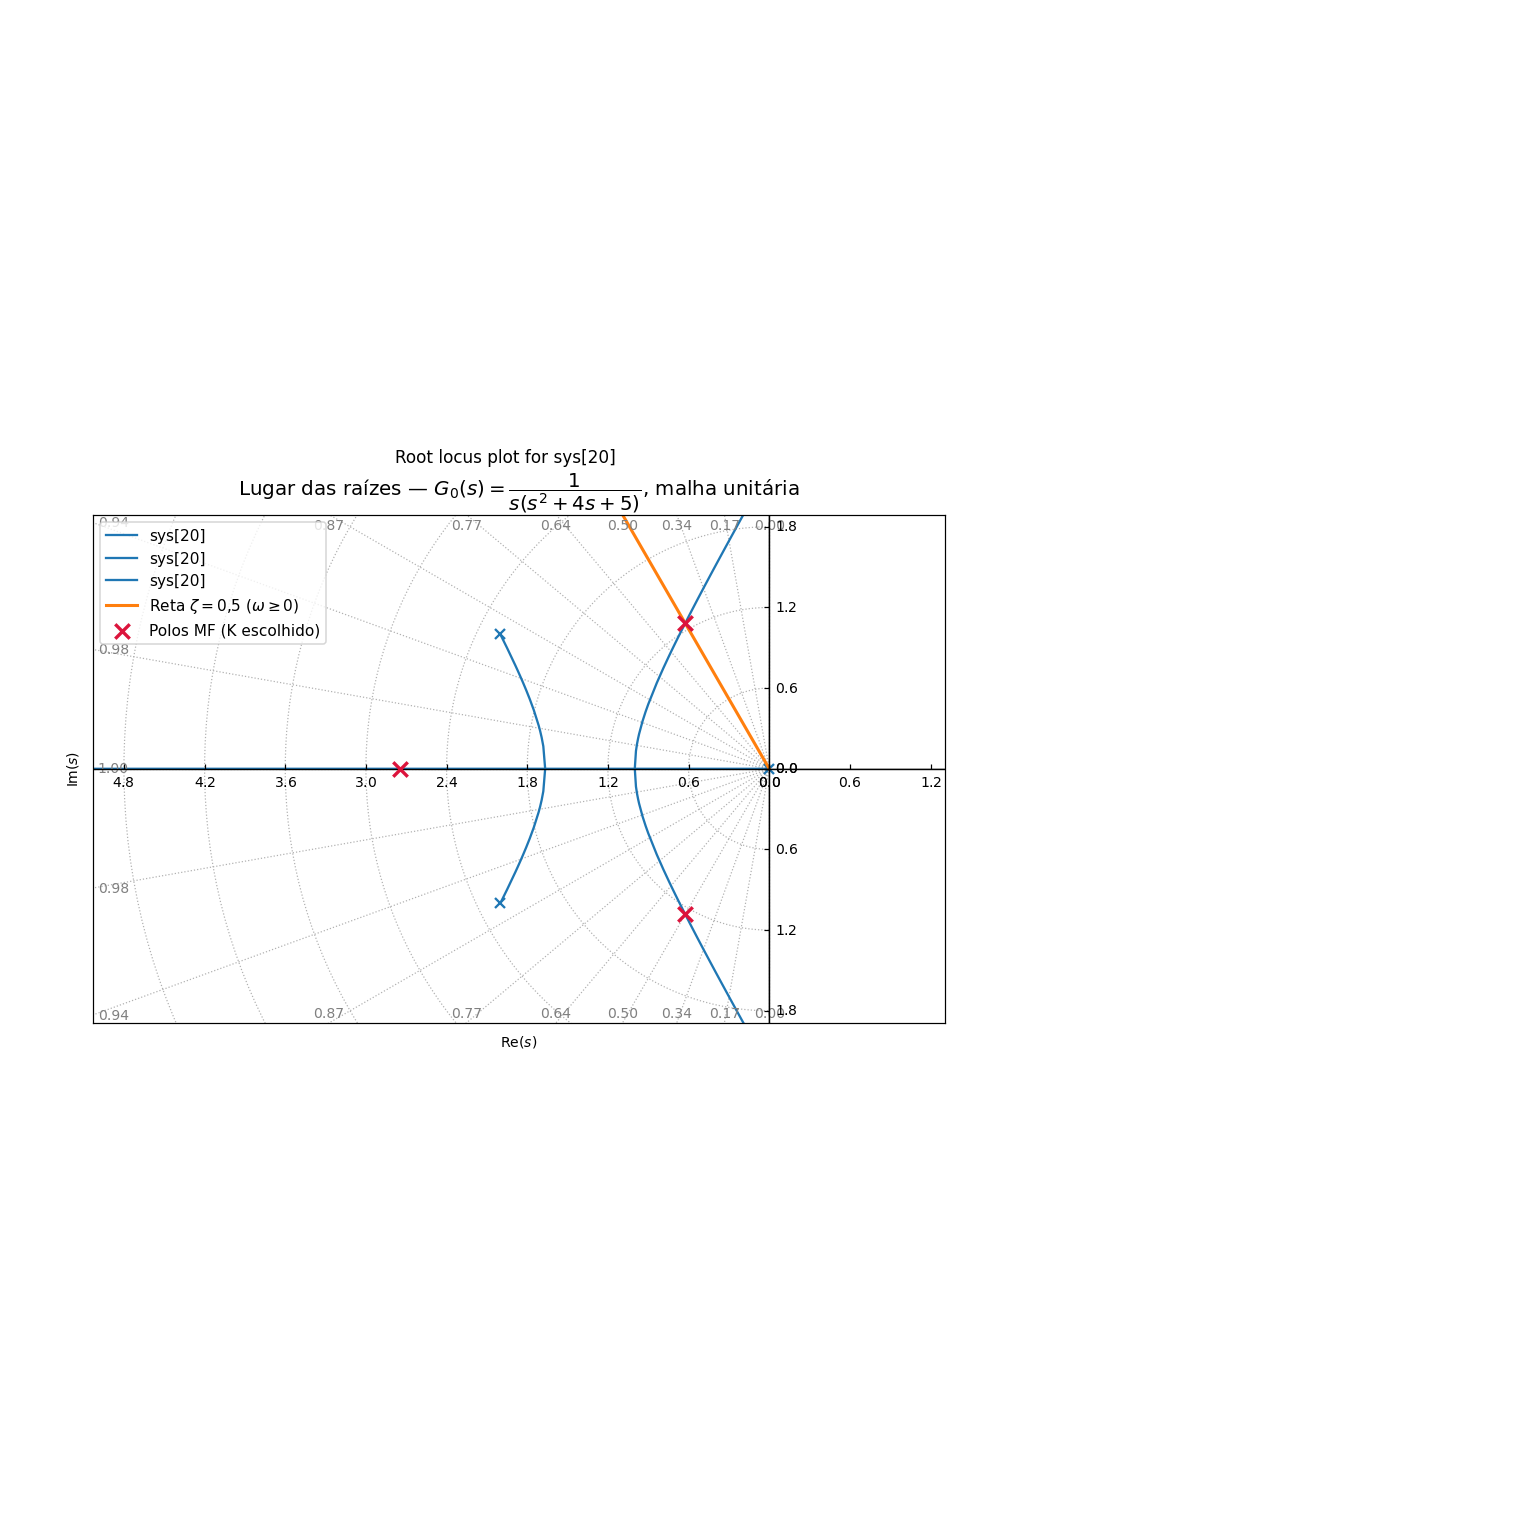

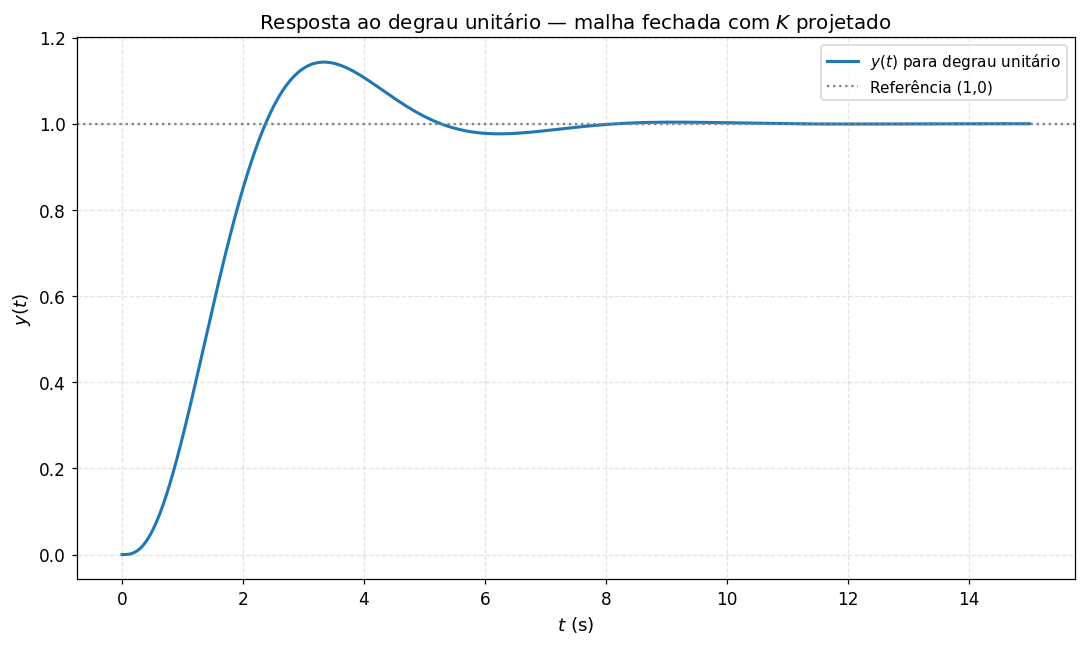

In [3]:
"""
Exercício B.6.14 — lugar das raízes, projeto por ζ=0.5 e resposta ao degrau.
Usa a biblioteca `control` (python-control) e Matplotlib para gráficos formatados.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

# ---------------------------------------------------------------------------
# Configuração visual global — melhora legibilidade das figuras e da impressão
# ---------------------------------------------------------------------------
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"control\.rlocus",
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

def planta_sem_ganho() -> ct.TransferFunction:
    """Retorna G0(s) = 1/(s(s²+4s+5)), ou seja, G(s) = K·G0(s)."""
    num = [1.0]
    den = [1.0, 4.0, 5.0, 0.0]  # (s²+4s+5)·s = s³+4s²+5s
    return ct.tf(num, den)


def angulo_eixo_zeta(zeta: float) -> float:
    """
    Ângulo θ no plano s (eixo real positivo) para semi-reta de ζ constante (ω≥0).
    θ = π − arccos(ζ).
    """
    phi = np.arccos(zeta)
    return float(np.pi - phi)


def parte_imag_sem_k(r: np.ndarray | float, theta: float) -> np.ndarray:
    """Parte imaginária de s³+4s²+5s com s = r·exp(jθ); aceita escalar ou vetor r."""
    r_arr = np.asarray(r, dtype=float)
    s = r_arr * np.exp(1j * theta)
    return np.imag(s**3 + 4 * s**2 + 5 * s)


def ganho_k_intersecao_zeta(sys_k1: ct.TransferFunction, zeta: float) -> tuple[float, complex]:
    """
    Localiza o primeiro cruzamento (r>0) da semi-reta s=r·exp(jθ) com a condição
    Im{s³+4s²+5s}=0 e devolve K=-(s³+4s²+5s) e o polo complexo em SP superior.
    """
    theta = angulo_eixo_zeta(zeta)

    eps, r_max = 1e-9, 50.0
    rs = np.linspace(eps, r_max, 80000)
    ims = parte_imag_sem_k(rs, theta)
    idx = np.where(np.diff(np.signbit(ims)))[0]
    if len(idx) == 0:
        raise RuntimeError("Não foi encontrada interseção da reta ζ com o lugar das raízes.")

    r_lo, r_hi = rs[idx[0]], rs[idx[0] + 1]

    def imag_escalar(rr: float) -> float:
        return float(parte_imag_sem_k(rr, theta))

    r_star = brentq(imag_escalar, r_lo, r_hi)

    s_star = r_star * np.exp(1j * theta)
    k_star = float(np.real(-(s_star**3 + 4 * s_star**2 + 5 * s_star)))
    return k_star, s_star


def malha_fechada_com_k(sys_k1: ct.TransferFunction, k: float) -> ct.TransferFunction:
    """T(s) com realimentação unitária negativa e ganho K sobre G0."""
    return ct.feedback(k * sys_k1, 1)


def imprimir_relatorio(zeta: float, k: float, polos: np.ndarray, sys_cl: ct.TransferFunction) -> None:
    """Imprime resultados principais de forma organizada no notebook/console."""
    sep = "=" * 72
    print(sep)
    print(f" PROJETO POR AMORTECIMENTO — ζ desejado (polos dominantes) = {zeta:g}")
    print(sep)
    print(f" Ganho K encontrado (interseção com reta ζ): K = {k:.12g}")
    print(f" K racional (referência analítica): K = 275/64 = {275.0/64.0:.12g}")
    print()
    print(" Polos em malha fechada (rad/s):")
    for i, p in enumerate(np.sort_complex(polos), start=1):
        mag = abs(p)
        zeta_p = float(-np.real(p) / mag) if mag > 1e-12 else float("nan")
        print(f"   p{i}: {np.real(p):+.6f} {np.imag(p):+.6f} j   |s|={mag:.6f}   ζ≈{zeta_p:.6f}")
    print()
    dc_gain = ct.dcgain(sys_cl)
    print(f" Ganho DC da malha fechada T(0) = {float(dc_gain):.12g}")
    print(sep)


def plot_lugar_raizes(sys_k1: ct.TransferFunction, k: float, zeta: float) -> None:
    """Gráfico do lugar das raízes + marcação do ganho K escolhido."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        ct.root_locus_plot(sys_k1, plot=True, grid=True)

    ax = plt.gca()

    # Semi-reta ζ no semi-plano superior (referência geométrica)
    th = angulo_eixo_zeta(zeta)
    r_line = np.linspace(0.0, 8.0, 400)
    s_line = r_line * np.exp(1j * th)
    ax.plot(
        np.real(s_line),
        np.imag(s_line),
        color="#ff7f0e",
        linewidth=2.0,
        label=r"Reta $\zeta = 0{,}5$ ($\omega \geq 0$)",
    )

    # Polos em MF para o K calculado
    cl_k = malha_fechada_com_k(sys_k1, k)
    polos = ct.poles(cl_k)
    ax.scatter(
        np.real(polos),
        np.imag(polos),
        s=90,
        c="crimson",
        marker="x",
        linewidths=2.2,
        label="Polos MF (K escolhido)",
        zorder=5,
    )

    ax.set_title(r"Lugar das raízes — $G_0(s)=\dfrac{1}{s(s^2+4s+5)}$, malha unitária")
    ax.set_xlabel(r"$\mathrm{Re}(s)$")
    ax.set_ylabel(r"$\mathrm{Im}(s)$")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(0.0, color="black", linewidth=0.8)
    ax.legend(loc="best")
    plt.tight_layout()


def plot_resposta_degrau(sys_cl: ct.TransferFunction, t_final: float = 15.0) -> None:
    """Resposta ao degrau unitário da malha fechada."""
    t = np.linspace(0.0, t_final, 4000)
    tout, yout = ct.step_response(sys_cl, t)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, color="#1f77b4", linewidth=2.0, label=r"$y(t)$ para degrau unitário")
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1.5, label="Referência (1,0)")
    ax.set_title("Resposta ao degrau unitário — malha fechada com $K$ projetado")
    ax.set_xlabel(r"$t$ (s)")
    ax.set_ylabel(r"$y(t)$")
    ax.legend(loc="best")
    plt.tight_layout()


# --- Execução (rode esta célula no Jupyter para gerar texto e figuras) ---
zeta_desejado = 0.5

sys_g0 = planta_sem_ganho()

K, s_dom_complexo = ganho_k_intersecao_zeta(sys_g0, zeta_desejado)
sys_cl = malha_fechada_com_k(sys_g0, K)
polos_mf = ct.poles(sys_cl)

imprimir_relatorio(zeta_desejado, K, polos_mf, sys_cl)

plot_lugar_raizes(sys_g0, K, zeta_desejado)
plt.show()

plot_resposta_degrau(sys_cl)
plt.show()
